# Task 2 (with Task 3)

In [1]:
!git clone -b dev https://github.com/vvsalash/efficient-dl-systems.git

Cloning into 'efficient-dl-systems'...
remote: Enumerating objects: 1575, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 1575 (delta 128), reused 167 (delta 102), pack-reused 1377 (from 1)
Receiving objects: 100% (1575/1575), 109.26 MiB | 16.49 MiB/s, done.
Resolving deltas: 100% (712/712), done.


In [2]:
%cd efficient-dl-systems/week03_data_parallel/homework/

/kaggle/working/efficient-dl-systems/week03_data_parallel/homework


In [3]:
!pip install pytest

### Benchmarking the training pipeline

In [4]:
!torchrun --nproc_per_node 2 ddp_cifar100.py --impl custom --device cuda --backend nccl --grad_accum_steps 2
!torchrun --nproc_per_node 2 ddp_cifar100.py --impl torch  --device cuda --backend nccl --grad_accum_steps 2

W0211 11:01:25.512000 117 torch/distributed/run.py:774] 
W0211 11:01:25.512000 117 torch/distributed/run.py:774] *****************************************
W0211 11:01:25.512000 117 torch/distributed/run.py:774] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0211 11:01:25.512000 117 torch/distributed/run.py:774] *****************************************
100%|████████████████████████████████████████| 169M/169M [00:10<00:00, 15.6MB/s]
100%|████████████████████████████████████████| 169M/169M [00:15<00:00, 11.2MB/s]
epoch=0 iter=0 loss=4.7880 acc=0.0156 do_step=False
epoch=0 iter=51 loss=4.6276 acc=0.0207 do_step=True
epoch=0 iter=102 loss=4.5449 acc=0.0262 do_step=False
epoch=0 iter=153 loss=4.4988 acc=0.0327 do_step=True
epoch=0 iter=204 loss=4.4604 acc=0.0379 do_step=False
epoch=0 iter=255 loss=4.4307 acc=0.0421 do_step=True
e

### Tests for SyncBatchNorm

In [5]:
!pytest -q test_syncbn.py

................                                                         [100%]
16 passed in 50.86s


### Performance benchmarks

In [10]:
!torchrun --nproc_per_node 2 bench_syncbn.py --impl custom --backend nccl --device cuda
!torchrun --nproc_per_node 2 bench_syncbn.py --impl torch  --backend nccl --device cuda

W0211 11:04:57.168000 1086 torch/distributed/run.py:774] 
W0211 11:04:57.168000 1086 torch/distributed/run.py:774] *****************************************
W0211 11:04:57.168000 1086 torch/distributed/run.py:774] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0211 11:04:57.168000 1086 torch/distributed/run.py:774] *****************************************
impl=custom world_size=2 device=cuda:0
   hid   bs    ms/iter     peakMB
   128   32      1.303        0.1
   128   64      1.321        0.3
   256   32      1.405        0.3
   256   64      1.432        0.5
   512   32      1.390        0.5
   512   64      1.284        1.0
  1024   32      1.484        1.1
  1024   64      1.372        2.1
W0211 11:05:03.550000 1118 torch/distributed/run.py:774] 
W0211 11:05:03.550000 1118 torch/distributed/run.py:774] *****************

# Task 4

список команд, которые я запускал на сервере

In [ ]:
!git clone -b dev https://github.com/vvsalash/efficient-dl-systems.git

In [ ]:
%cd efficient-dl-systems/week03_data_parallel/homework/

In [ ]:
!pip install -r requirements.txt

In [ ]:
!chmod +x ring_vs_torch.sh
!chmod +x ring.sh
!chmod +x butterfly.sh

In [ ]:
./ring_vs_torch.sh

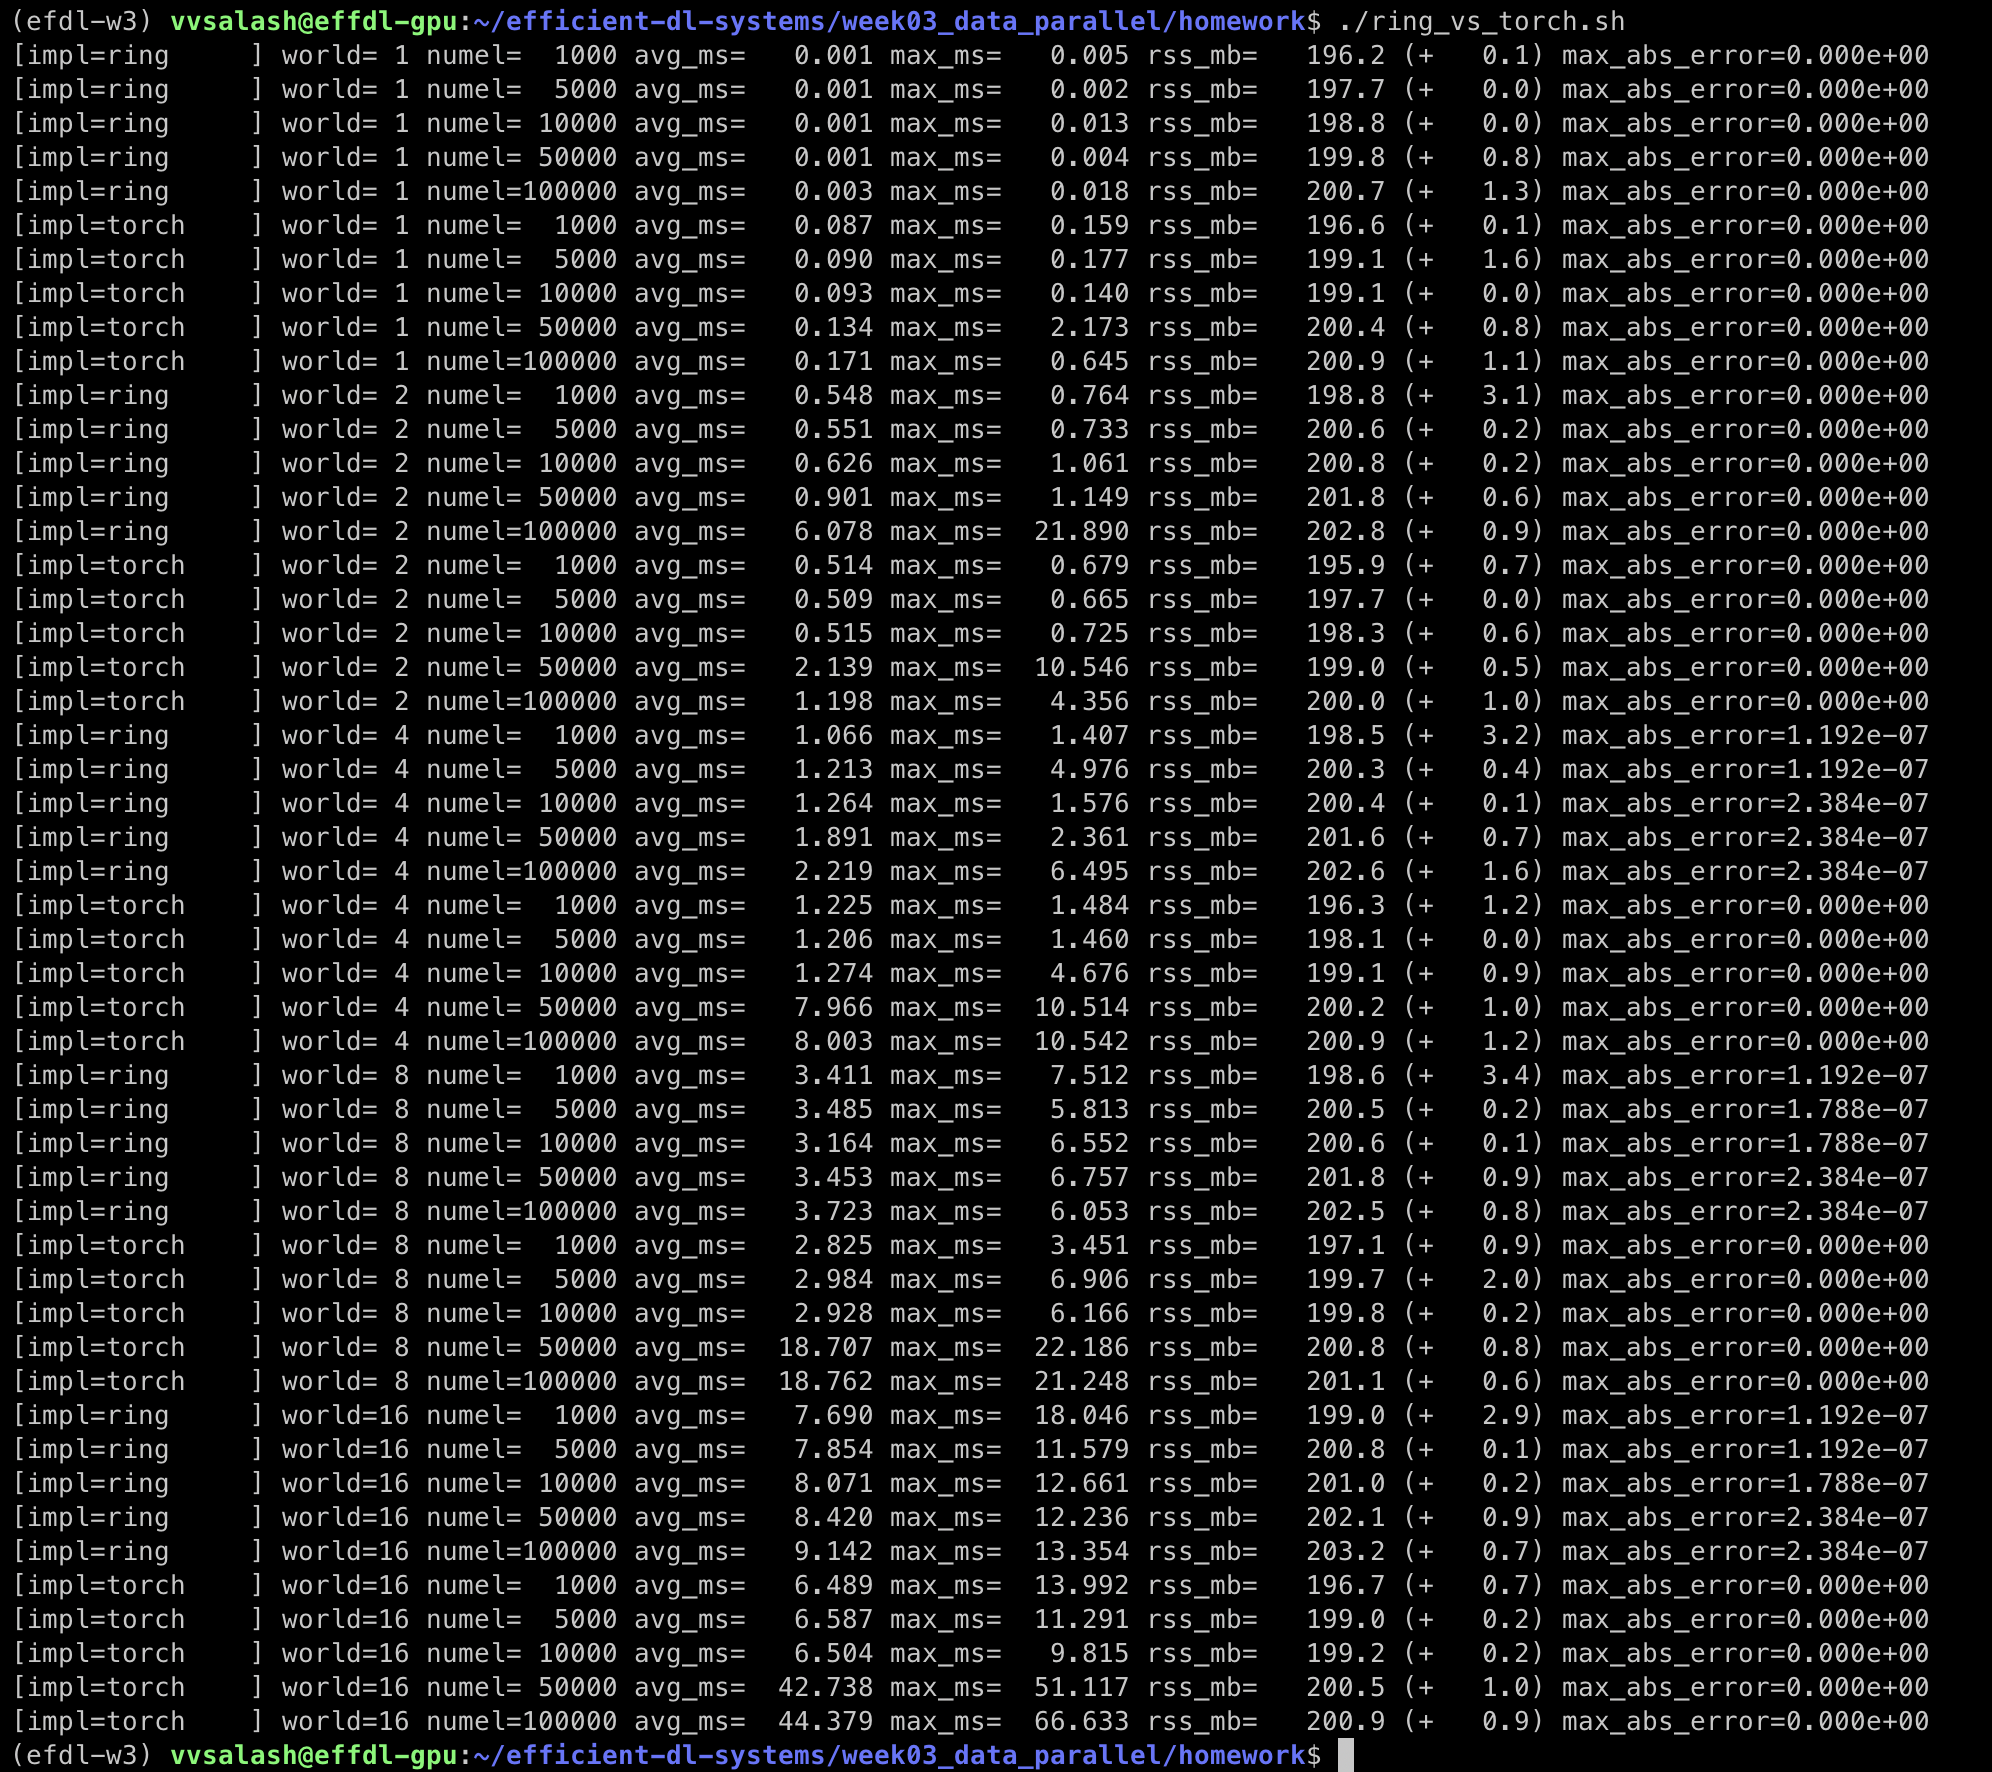

In [ ]:
./ring.sh

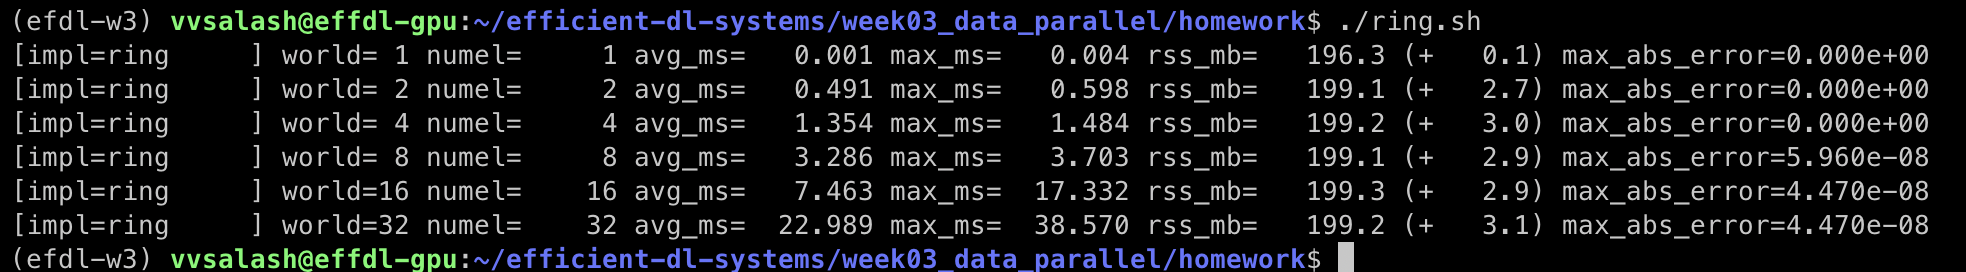

In [ ]:
./butterfly.sh

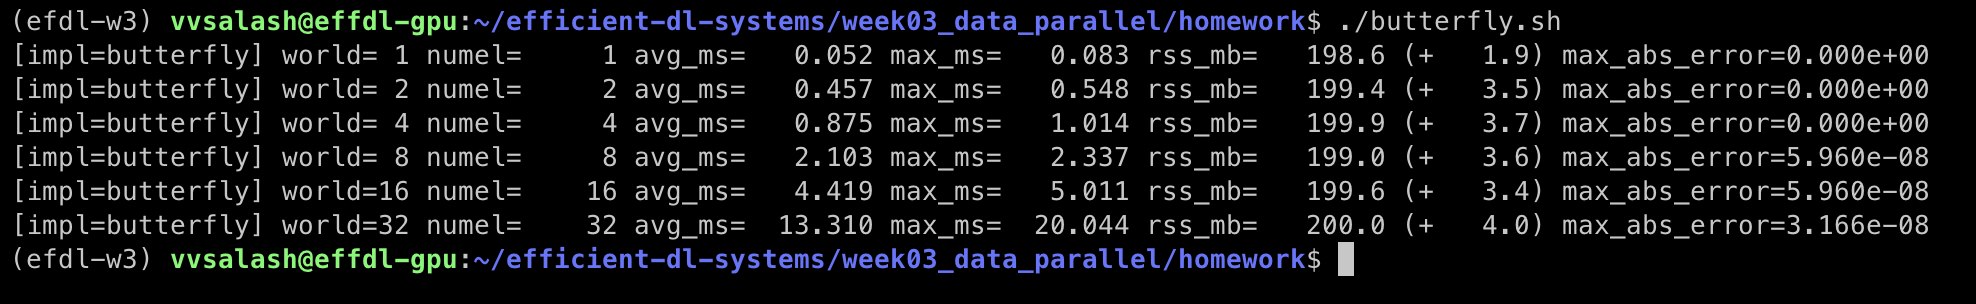